In [1]:
import torch
from utils import do_2D_pca, load_image, resize_crop
import torch.nn.functional as F
import matplotlib.pyplot as plt
from functorch import vmap
from vit_wrapper import (
    PretrainedViTWrapper,
    MODEL_MAP,
    FeatureType,
    MODEL_LIST,
)
import numpy as np

/home/ab_aimd_anja_20884/anaconda3/envs/moritz_eng_new/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def normalize(t_tens):
    return (t_tens - t_tens.min())/(t_tens.max() - t_tens.min())

In [3]:
import torch
import math

def translate_tensor_wrap(x: torch.Tensor, step_x: int = 0, step_y: int = 0) -> torch.Tensor:
    """
    Circularly translate tensor using wrap boundary conditions.

    Args:
        x: Tensor of shape (B, C, H, W)
        step_x: horizontal shift in pixels; positive -> right
        step_y: vertical shift in pixels; positive -> down

    Returns:
        Tensor of same shape (B, C, H, W) translated with wrap (circular) boundary.
    """
    
    if not isinstance(step_x, (int,)) or not isinstance(step_y, (int,)):
        print(type(step_x), type(step_y))
        raise ValueError("translate_tensor_wrap expects integer step_x and step_y for exact circular wrap.")
    # torch.roll uses order: dims (H dim index 2, W dim index 3)
    return torch.roll(x, shifts=(step_y, step_x), dims=(2, 3))


def revert_translation_wrap(feat: torch.Tensor, step_x: int = 0, step_y: int = 0, scale_factor: int = 14,
                            require_exact_division: bool = True) -> torch.Tensor:
    """
    Revert an image-space integer translation on a feature map using circular wrapping.
    The original translation is in *image pixels*; we convert to feature pixels by dividing by scale_factor.

    Args:
        feat: Tensor of shape (B, C, Hf, Wf)  (e.g. (1, 384, H//14, W//14))
        step_x: original image translation (pixels, int)
        step_y: original image translation (pixels, int)
        scale_factor: integer scaling between image and feature map spatial dims (e.g. 14)
        require_exact_division: if True, require that step_x/scale_factor and step_y/scale_factor are integers.
                                If False, the feature shift will be rounded to nearest integer.

    Returns:
        Tensor of same shape (B, C, Hf, Wf) where the translation is reverted using circular wrap.
    """
    if not isinstance(step_x, (int,)) or not isinstance(step_y, (int,)):
        raise ValueError("step_x and step_y must be integers (image pixels).")

    # convert to feature-map pixels (float)
    fx = step_x / float(scale_factor)
    fy = step_y / float(scale_factor)

    # check divisibility if requested
    if require_exact_division:
        if not fx.is_integer() or not fy.is_integer():
            raise ValueError(f"Translation {step_x},{step_y} not divisible by scale_factor={scale_factor}. "
                             "Resulting feature shift would be fractional. "
                             "Set require_exact_division=False to allow rounding.")
        fx = int(fx)
        fy = int(fy)
    else:
        # round to nearest integer feature shift
        fx = int(round(fx))
        fy = int(round(fy))

    # to revert the original translation we roll in the opposite direction
    return torch.roll(feat, shifts=(-fy, -fx), dims=(2, 3))


In [4]:
model = PretrainedViTWrapper(MODEL_LIST[1], add_flash_attn=False, device="cuda")

In [5]:
img_size = 2*518

In [6]:
img = load_image("images/black_square_518.png", resize_crop((img_size, img_size),(img_size, img_size)))[0]

In [11]:
def translate_14(img, x_step, y_step, plot:bool=False):
    '''
    step refers to the step in the feature tensor
    '''
    if isinstance(x_step, np.ndarray) and isinstance(x_step, np.ndarray):
        x_step, y_step = x_step*14, y_step*14
        tensor_list = []
        for x_step_, y_step_ in zip(x_step, y_step):
            tensor_list.append(translate_tensor_wrap(img.to("cpu"), step_x=int(x_step_), step_y=int(y_step_)))
        #tensor_list.reverse()
        batched_tensor = torch.concat(tensor_list, dim=0)
        #print(f"{batched_tensor.shape=}")

        #inference
        with torch.inference_mode(): 
            pred = model.forward_features(batched_tensor.to("cuda").float(), make_2D=True).to("cpu")
        #print(f"{pred.shape}")

        res_list = []
        for x_step_, y_step_, pred_ in zip (x_step, y_step, pred):
            res_list.append(revert_translation_wrap(pred_.unsqueeze(0), step_x=int(x_step_), step_y=int(y_step_), scale_factor=14, require_exact_division=False))#.detach().cpu().squeeze().transpose(2, 0).float()
        
        batched_res = torch.concat(res_list, dim=0)
        return batched_res
    else:
        x_step, y_step = x_step*14, y_step*14
        t_tens = translate_tensor_wrap(img.to("cpu"), step_x=x_step, step_y=y_step)
        print(t_tens.shape)

        # inference
        with torch.inference_mode(): 
            pred = model.forward_features(t_tens.to("cuda").float(), make_2D=True).to("cpu")
        print(f"{pred.shape}")

        un_ten = revert_translation_wrap(pred, step_x=x_step, step_y=y_step, scale_factor=14, require_exact_division=False)#.detach().cpu().squeeze().transpose(2, 0).float()
    
        if plot:
            plt_t_tens= t_tens.clone().detach().cpu().squeeze().transpose(2, 0).float()
            fig, ax = plt.subplots(1, 4, figsize=(15, 5))
            ax[0].imshow(normalize(img.detach().cpu().squeeze().transpose(2, 0).float()))
            ax[0].set_title("orig image")
            ax[1].imshow(normalize(plt_t_tens))
            ax[1].set_title("translated image")
            ax[2].imshow(do_2D_pca(pred.squeeze(), post_norm="minmax"))
            ax[2].set_title("translated_prediction")
            ax[3].imshow(do_2D_pca(un_ten.squeeze(), post_norm="minmax"))
            ax[3].set_title("untranslated prediction image")

        return un_ten


import time
def batched_translate_and_predict(img, x_step, y_step, scale_factor=14, device="cuda"):
    # ensure img has batch dim
    if img.dim() == 3:
        img = img.unsqueeze(0)   # (1, C, H, W)
    # move once to device
    img = img.to(device)

    # convert steps to ints and scale if needed
    x_steps = [int(x * 14) for x in x_step]  # or x_step already scaled
    y_steps = [int(y * 14) for y in y_step]

    start = time.perf_counter()
    # Build batched translated tensor (on device)
    translated_list = [torch.roll(img, shifts=(ys, xs), dims=(2, 3)) 
                       for xs, ys in zip(x_steps, y_steps)]
    #print("time for rolling =", time.perf_counter() - start)
    batched_tensor = torch.cat(translated_list, dim=0)   # shape (N, C, H, W)

    # Inference in single batch on GPU
    start = time.perf_counter()
    with torch.inference_mode():
        pred = model.forward_features(batched_tensor.float(), make_2D=True)  # stays on device
    #print("time for inference =", time.perf_counter() - start)

    # Revert translations on the predictions (inverse roll)
    # assume pred shape (N, featC, featH, featW)
    start = time.perf_counter()
    reverted_list = [torch.roll(p.unsqueeze(0), shifts=(-ys//14, -xs//14), dims=(2, 3))
                     for p, xs, ys in zip(pred, x_steps, y_steps)]
    batched_res = torch.cat(reverted_list, dim=0)  # (N, featC, featH, featW)
    #print("time for unrolling =", time.perf_counter() - start)

    # optional: move to cpu if you need
    return batched_res

In [15]:
#from tqdm 
import tqdm
from itertools import batched

x = np.array(range(1, img_size//28))*2

y = x.copy()
x_steps, y_steps = np.meshgrid(x, y)
#print()

x_batches = list(batched(x_steps.flatten(), x.shape[0]))
y_batches = list(batched(y_steps.flatten(), x.shape[0]))



res = torch.zeros((1, 384, img_size//14, img_size//14)).to("cuda")
for x, y in tqdm.tqdm(zip(x_batches, y_batches)):
    #print(res.shape, translate_14(img, x_step=int(x), y_step=int(y)).)
    start = time.perf_counter()        
    res = batched_translate_and_predict(img, x_step=np.array(x), y_step=np.array(y)).sum(0)
    #print("time until_res_add", time.perf_counter() - start)
    #print(intermediate.shape)

mean_res = res/x_steps.flatten().shape[0]

36it [01:48,  3.01s/it]


In [ ]:
# import tifffile 
# tifffile.imwrite("default_img_trans_mean.tiff", mean_res.numpy())

In [ ]:
# torch.save(mean_res, "default_img_trans_mean.pt")

In [16]:
mean_res.shape

torch.Size([384, 74, 74])

(array([2.7000e+01, 5.3000e+01, 7.7000e+01, 5.4000e+01, 5.0000e+01,
        4.0000e+01, 7.1000e+01, 4.4000e+01, 4.9000e+01, 2.5000e+01,
        1.7000e+01, 1.4000e+01, 3.6000e+01, 6.3000e+01, 4.7000e+01,
        4.2000e+01, 5.6000e+01, 5.3000e+01, 5.1000e+01, 4.3000e+01,
        4.2000e+01, 5.7000e+01, 3.8000e+01, 2.3000e+01, 1.9000e+01,
        6.7000e+01, 4.1000e+01, 2.9000e+01, 1.8000e+01, 2.6000e+01,
        2.9000e+01, 1.9000e+01, 1.0000e+01, 4.0000e+00, 2.4000e+01,
        2.3000e+01, 2.0000e+01, 5.0000e+00, 0.0000e+00, 2.7000e+01,
        2.1000e+01, 2.3000e+01, 3.0000e+00, 2.9000e+01, 1.8000e+01,
        4.3000e+01, 4.0000e+01, 6.9000e+01, 1.0700e+02, 6.4000e+01,
        1.0200e+02, 6.2000e+01, 5.5000e+01, 5.6000e+01, 6.7000e+01,
        7.9000e+01, 8.1000e+01, 8.0000e+01, 5.0000e+01, 6.7000e+01,
        7.7000e+01, 7.4000e+01, 7.5000e+01, 1.0500e+02, 1.1000e+02,
        9.1000e+01, 9.3000e+01, 7.8000e+01, 9.9000e+01, 1.2500e+02,
        1.3800e+02, 1.5200e+02, 1.5500e+02, 1.55

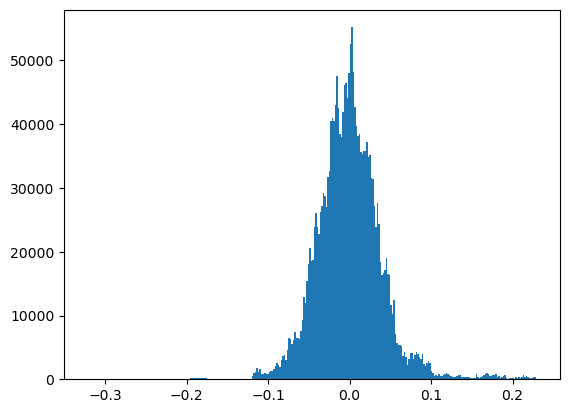

In [23]:
plt.hist(mean_res.cpu().flatten(), bins=300)

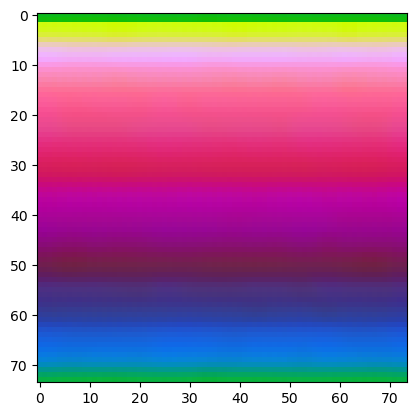

In [17]:
plt.imshow(do_2D_pca(mean_res.squeeze(), post_norm="minmax"))

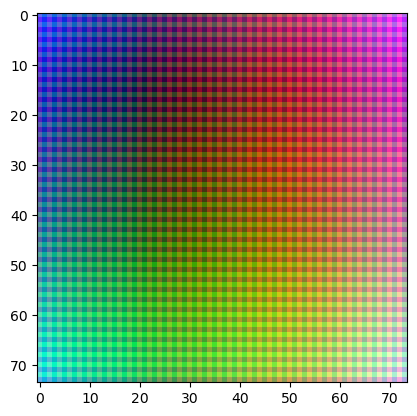

In [ ]:
#old working_one
#plt.imshow(do_2D_pca(mean_res.squeeze(), post_norm="minmax"))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4335513..0.476272].


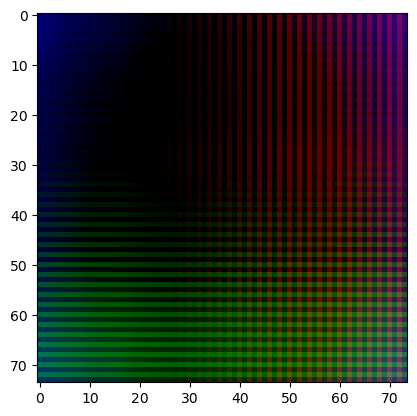

In [ ]:
for row in mean_res:
    plt.imshow(do_2D_pca(row))

(array([3.6100e+02, 9.6800e+02, 1.1030e+03, 1.0840e+03, 9.0400e+02,
        6.1200e+02, 3.1500e+02, 1.0700e+02, 2.2000e+01, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.00

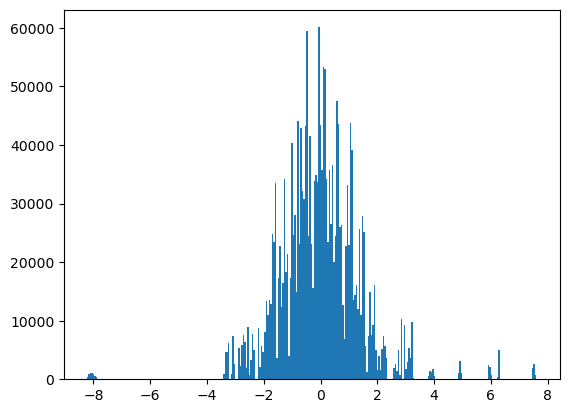

In [ ]:
plt.hist(mean_res.flatten(), bins=300)

In [18]:
res  =batched_translate_and_predict(img, x_step=np.array([15, 15, 30]), y_step=np.array([15, 30, 30]))

In [19]:
res.shape

torch.Size([3, 384, 74, 74])

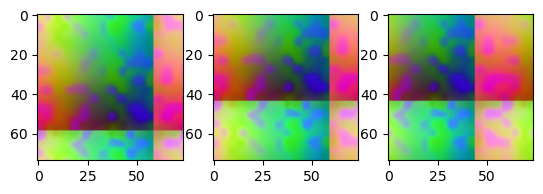

In [20]:
fig, ax = plt.subplots(1, 3)

for ax, im in zip(ax, res):
    ax.imshow(do_2D_pca(im, post_norm="minmax"))

torch.Size([1, 3, 1036, 1036])
torch.Size([1, 384, 74, 74])


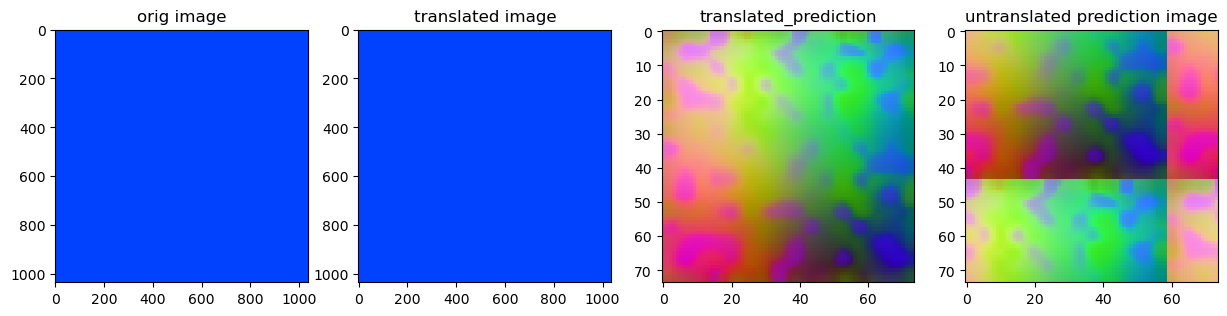

In [ ]:
un_trans_feats = translate_14(img, x_step=15, y_step=30, plot=True)

In [ ]:
un_trans_feats.shape

torch.Size([1, 384, 74, 74])